# Test: Do the 10-Node Parameters Oscillate?

Quick sanity check: simulate the 4 coupling architectures with both topologies
at fixed (P, K) values for T=5 min and visually confirm oscillatory dynamics.

We test several (P, K) combinations to locate the oscillatory regime.


In [1]:
import sys, os
import numpy as np
import matplotlib.pyplot as plt
sys.path.append('../')

from Scripts.parameters_10nodes import (
    N_nodes, param_nodes,
    M_ring, T_ho_ring,
    M_rand, T_ho_rand,
    dt, sigma_E,
)
from Scripts.simulation_10nodes import (
    simulate_wc_stochastic_10n,
    simulate_wc_additive_stochastic_10n,
    simulate_wc_ho_stochastic_10n,
    simulate_wc_ho_additive_stochastic_10n,
)

print(f'N_nodes = {N_nodes}')
print(f'Ring degrees: {M_ring.sum(axis=1).astype(int).tolist()}')
print(f'Random degrees: {M_rand.sum(axis=1).astype(int).tolist()}')
print(f'thetaE per node: {[round(p["thetaE"], 3) for p in param_nodes]}')
print(f'thetaI per node: {[round(p["thetaI"], 3) for p in param_nodes]}')
print('OK')


[10-node] N = 10
  Ring-SW:  degrees = [5, 4, 5, 4, 4, 5, 4, 5, 4, 4], mean = 4.4, edges = 22
  Random :  degrees = [3, 7, 5, 3, 4, 2, 6, 3, 1, 2], mean = 3.6, edges = 18
[10-node] thetaE perturbations: [-0.011, -0.148, 0.29, 0.03, 0.282, -0.165, 0.24, -0.106, -0.102, 0.128]
[10-node] thetaI perturbations: [0.253, 0.469, 0.455, 0.431, 0.137, -0.1, -0.36, -0.113, -0.185, 0.111]
N_nodes = 10
Ring degrees: [5, 4, 5, 4, 4, 5, 4, 5, 4, 4]
Random degrees: [3, 7, 5, 3, 4, 2, 6, 3, 1, 2]
thetaE per node: [1.989, 1.852, 2.29, 2.03, 2.282, 1.835, 2.24, 1.894, 1.898, 2.128]
thetaI per node: [3.253, 3.469, 3.455, 3.431, 3.137, 2.9, 2.64, 2.887, 2.815, 3.111]
OK


## Single-point simulations at various (P, K) values

We test a grid of (P, K) combinations to see which ones produce oscillations.
For each, we run T=300s (5 min) and plot E signals for the first 3 nodes.


=== 2nd Order Additive — Ring Small-World ===


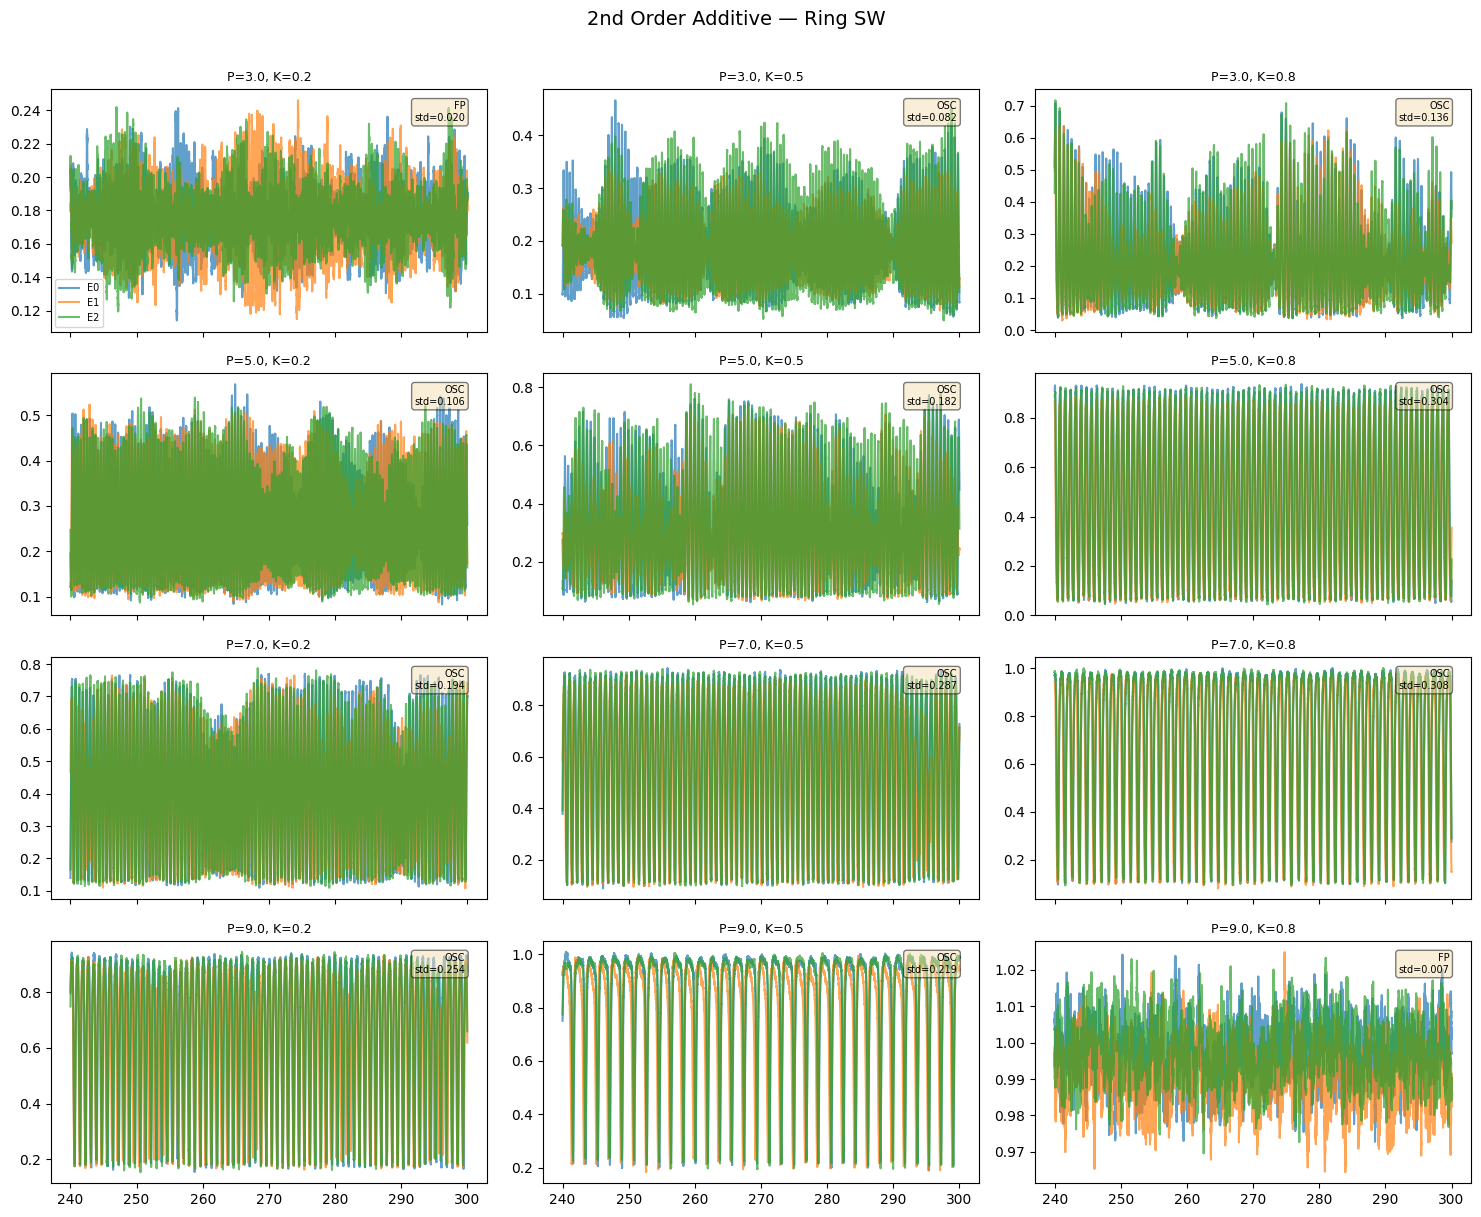

In [2]:
# Test parameters
P_test_values = [3.0, 5.0, 7.0, 9.0]
K_test_values = [0.2, 0.5, 0.8]
T_test = 300  # 5 minutes

# Fixed initial state
rng = np.random.default_rng(42)
state0 = 0.1 * rng.standard_normal(2 * N_nodes)

# ---- 2nd Order Additive, Ring SW ----
print('=== 2nd Order Additive — Ring Small-World ===')
fig, axes = plt.subplots(len(P_test_values), len(K_test_values),
                         figsize=(5*len(K_test_values), 3*len(P_test_values)),
                         sharex=True)

for ip, P_val in enumerate(P_test_values):
    for ik, K_val in enumerate(K_test_values):
        P_vec = np.full(N_nodes, P_val)
        t, states = simulate_wc_stochastic_10n(
            state0, P_vec, K_val, M_ring, T_test, dt, sigma_E=sigma_E)
        
        # Plot last 20% to skip transient
        start = int(0.8 * len(t))
        ax = axes[ip, ik]
        for node in range(3):
            ax.plot(t[start:], states[start:, node], alpha=0.7,
                    label=f'E{node}')
        ax.set_title(f'P={P_val}, K={K_val}', fontsize=9)
        if ip == 0 and ik == 0:
            ax.legend(fontsize=7)
        
        # Check amplitude as quick oscillation proxy
        E_last = states[start:, :N_nodes]
        amp = E_last.std(axis=0).mean()
        osc_label = 'OSC' if amp > 0.05 else 'FP'
        ax.text(0.95, 0.95, f'{osc_label}\nstd={amp:.3f}',
                transform=ax.transAxes, fontsize=7,
                verticalalignment='top', horizontalalignment='right',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

fig.suptitle('2nd Order Additive — Ring SW', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


=== 2nd Order Diffusive — Ring Small-World ===


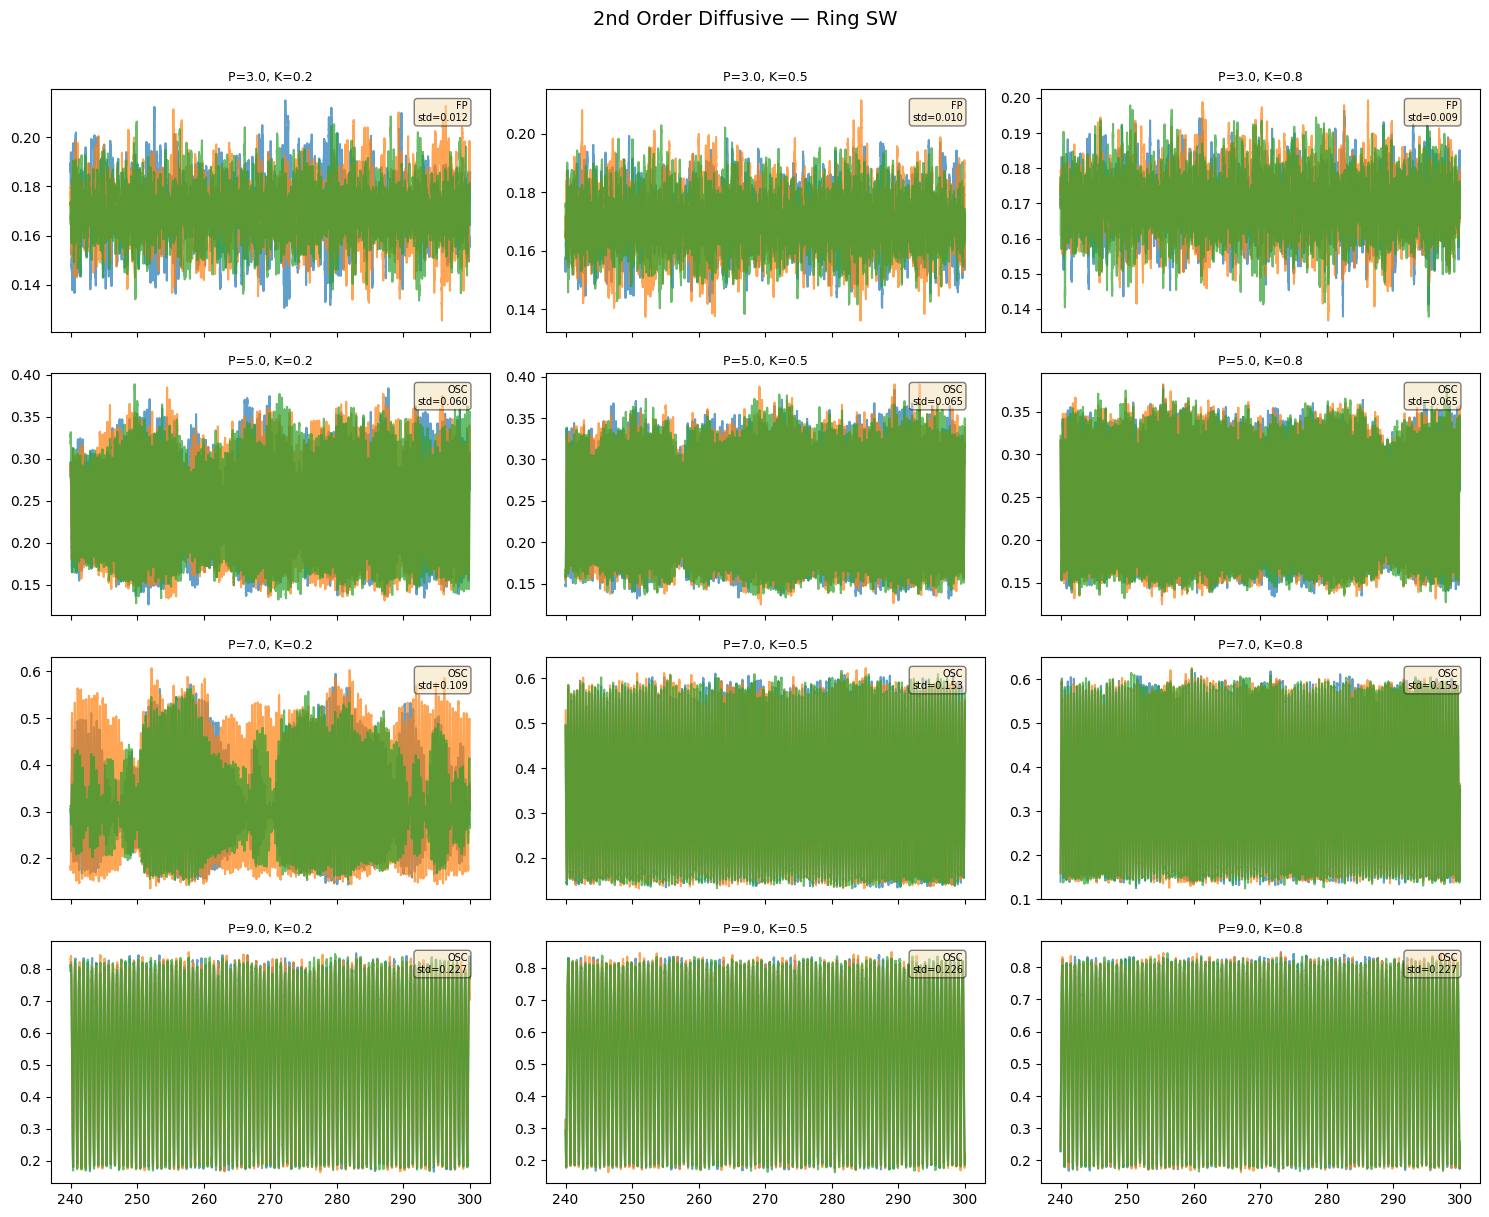

In [3]:
print('=== 2nd Order Diffusive — Ring Small-World ===')
fig, axes = plt.subplots(len(P_test_values), len(K_test_values),
                         figsize=(5*len(K_test_values), 3*len(P_test_values)),
                         sharex=True)

for ip, P_val in enumerate(P_test_values):
    for ik, K_val in enumerate(K_test_values):
        P_vec = np.full(N_nodes, P_val)
        t, states = simulate_wc_additive_stochastic_10n(
            state0, P_vec, K_val, M_ring, T_test, dt, sigma_E=sigma_E)
        start = int(0.8 * len(t))
        ax = axes[ip, ik]
        for node in range(3):
            ax.plot(t[start:], states[start:, node], alpha=0.7, label=f'E{node}')
        ax.set_title(f'P={P_val}, K={K_val}', fontsize=9)
        E_last = states[start:, :N_nodes]
        amp = E_last.std(axis=0).mean()
        osc_label = 'OSC' if amp > 0.05 else 'FP'
        ax.text(0.95, 0.95, f'{osc_label}\nstd={amp:.3f}',
                transform=ax.transAxes, fontsize=7,
                verticalalignment='top', horizontalalignment='right',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

fig.suptitle('2nd Order Diffusive — Ring SW', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


=== 3rd Order Additive — Ring Small-World ===


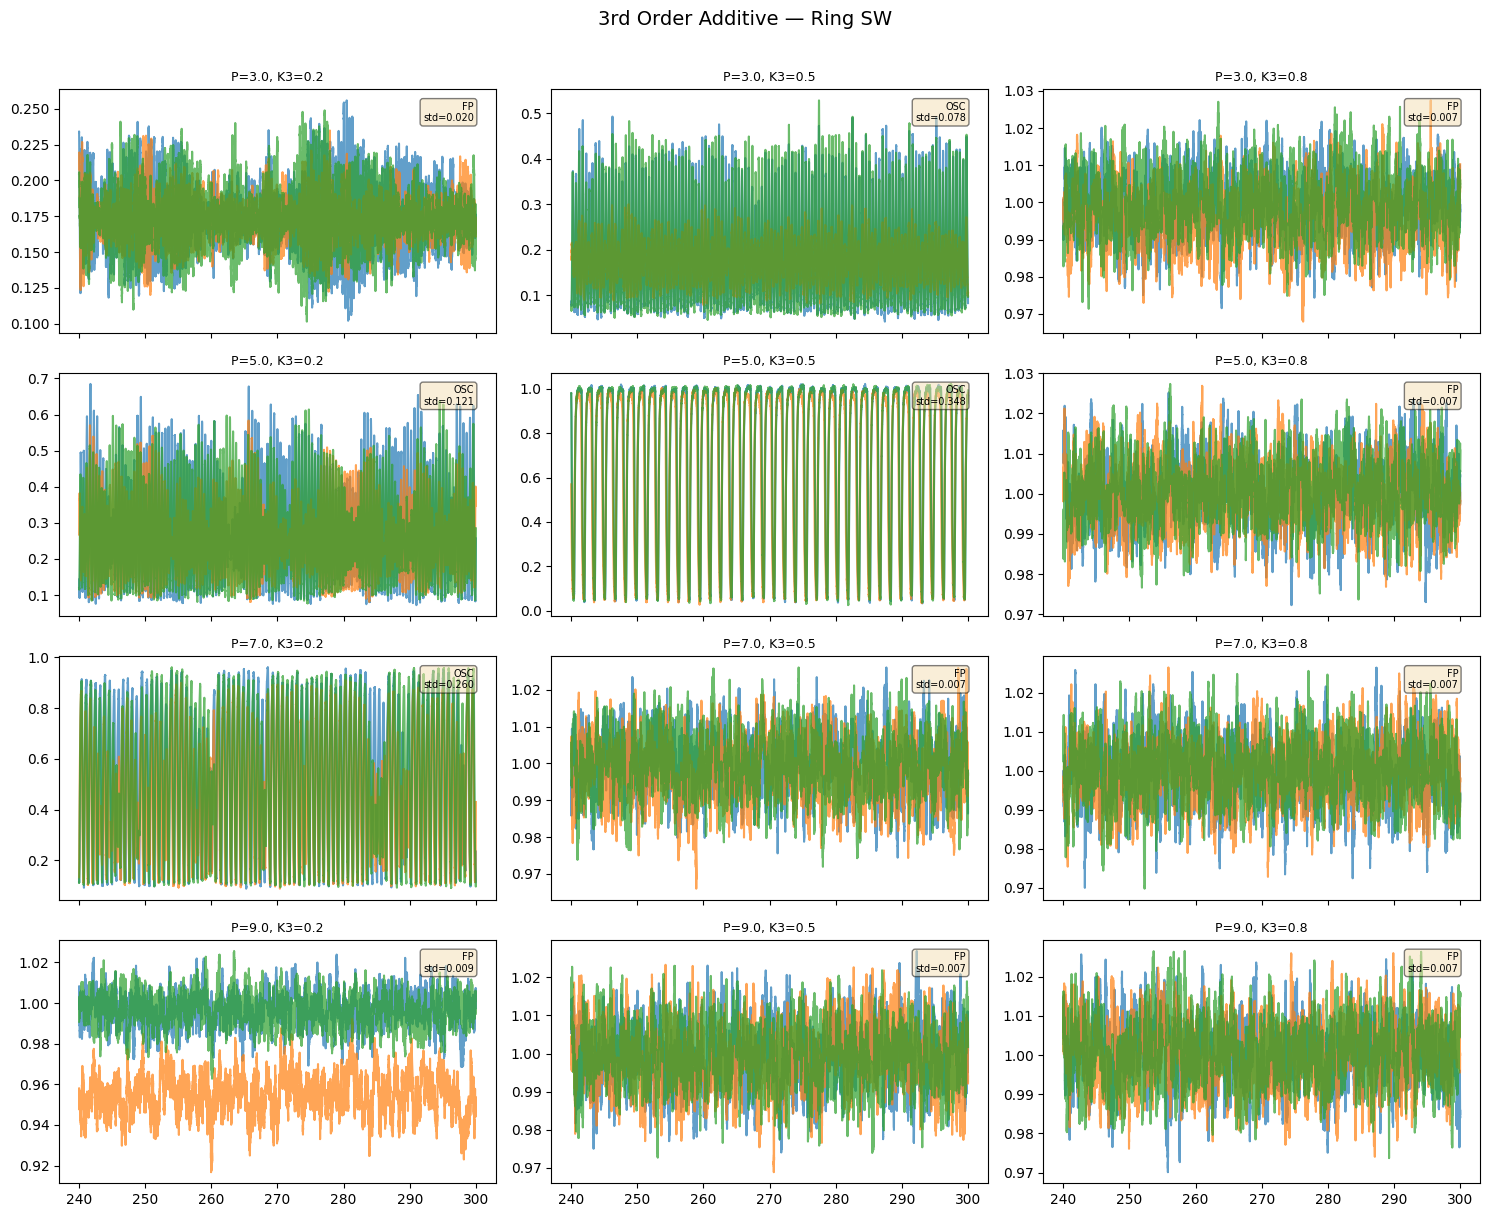

In [4]:
print('=== 3rd Order Additive — Ring Small-World ===')
fig, axes = plt.subplots(len(P_test_values), len(K_test_values),
                         figsize=(5*len(K_test_values), 3*len(P_test_values)),
                         sharex=True)

for ip, P_val in enumerate(P_test_values):
    for ik, K_val in enumerate(K_test_values):
        P_vec = np.full(N_nodes, P_val)
        t, states = simulate_wc_ho_stochastic_10n(
            state0, P_vec, K_val, T_ho_ring, T_test, dt, sigma_E=sigma_E)
        start = int(0.8 * len(t))
        ax = axes[ip, ik]
        for node in range(3):
            ax.plot(t[start:], states[start:, node], alpha=0.7, label=f'E{node}')
        ax.set_title(f'P={P_val}, K3={K_val}', fontsize=9)
        E_last = states[start:, :N_nodes]
        amp = E_last.std(axis=0).mean()
        osc_label = 'OSC' if amp > 0.05 else 'FP'
        ax.text(0.95, 0.95, f'{osc_label}\nstd={amp:.3f}',
                transform=ax.transAxes, fontsize=7,
                verticalalignment='top', horizontalalignment='right',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

fig.suptitle('3rd Order Additive — Ring SW', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


=== 3rd Order Diffusive — Ring Small-World ===


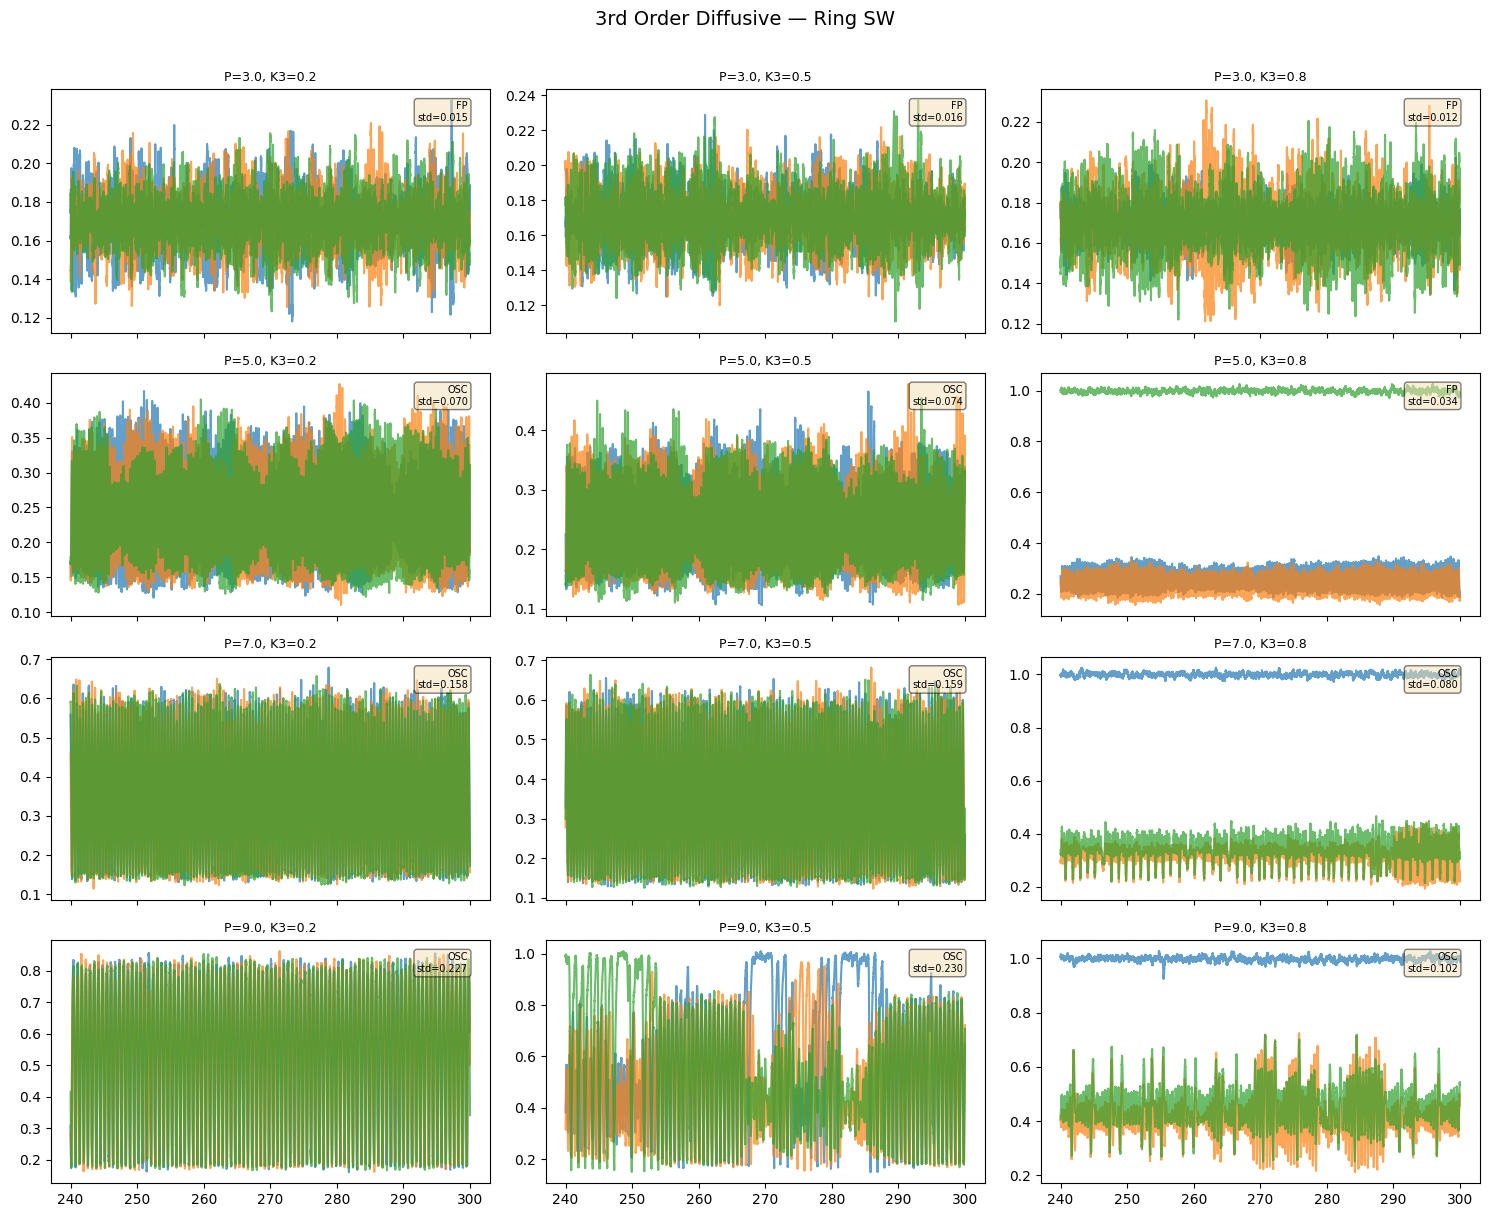

In [5]:
print('=== 3rd Order Diffusive — Ring Small-World ===')
fig, axes = plt.subplots(len(P_test_values), len(K_test_values),
                         figsize=(5*len(K_test_values), 3*len(P_test_values)),
                         sharex=True)

for ip, P_val in enumerate(P_test_values):
    for ik, K_val in enumerate(K_test_values):
        P_vec = np.full(N_nodes, P_val)
        t, states = simulate_wc_ho_additive_stochastic_10n(
            state0, P_vec, K_val, T_ho_ring, T_test, dt, sigma_E=sigma_E)
        start = int(0.8 * len(t))
        ax = axes[ip, ik]
        for node in range(3):
            ax.plot(t[start:], states[start:, node], alpha=0.7, label=f'E{node}')
        ax.set_title(f'P={P_val}, K3={K_val}', fontsize=9)
        E_last = states[start:, :N_nodes]
        amp = E_last.std(axis=0).mean()
        osc_label = 'OSC' if amp > 0.05 else 'FP'
        ax.text(0.95, 0.95, f'{osc_label}\nstd={amp:.3f}',
                transform=ax.transAxes, fontsize=7,
                verticalalignment='top', horizontalalignment='right',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

fig.suptitle('3rd Order Diffusive — Ring SW', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


## Same tests with Random topology


=== 2nd Order Additive — Random ===


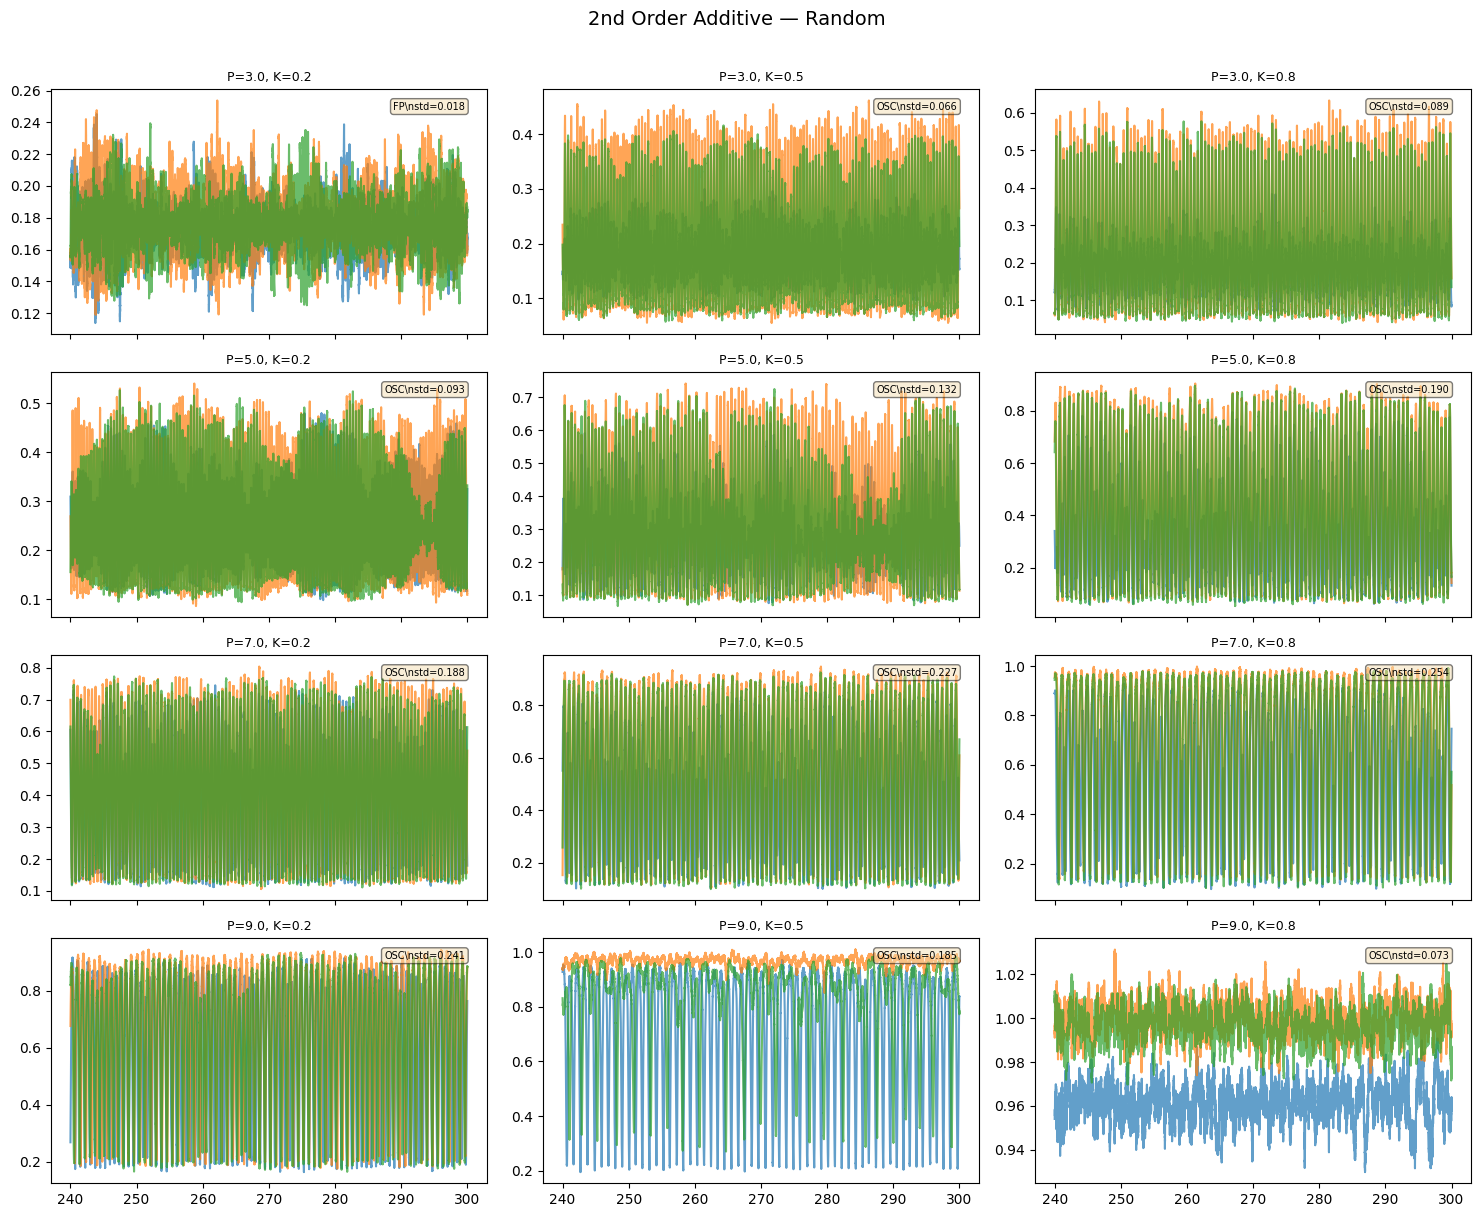

In [6]:
print('=== 2nd Order Additive — Random ===')
fig, axes = plt.subplots(len(P_test_values), len(K_test_values),
                         figsize=(5*len(K_test_values), 3*len(P_test_values)),
                         sharex=True)

for ip, P_val in enumerate(P_test_values):
    for ik, K_val in enumerate(K_test_values):
        P_vec = np.full(N_nodes, P_val)
        t, states = simulate_wc_stochastic_10n(
            state0, P_vec, K_val, M_rand, T_test, dt, sigma_E=sigma_E)
        start = int(0.8 * len(t))
        ax = axes[ip, ik]
        for node in range(3):
            ax.plot(t[start:], states[start:, node], alpha=0.7, label=f'E{node}')
        ax.set_title(f'P={P_val}, K={K_val}', fontsize=9)
        E_last = states[start:, :N_nodes]
        amp = E_last.std(axis=0).mean()
        osc_label = 'OSC' if amp > 0.05 else 'FP'
        ax.text(0.95, 0.95, f'{osc_label}\\nstd={amp:.3f}',
                transform=ax.transAxes, fontsize=7,
                verticalalignment='top', horizontalalignment='right',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

fig.suptitle('2nd Order Additive — Random', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


=== 2nd Order Diffusive — Random ===


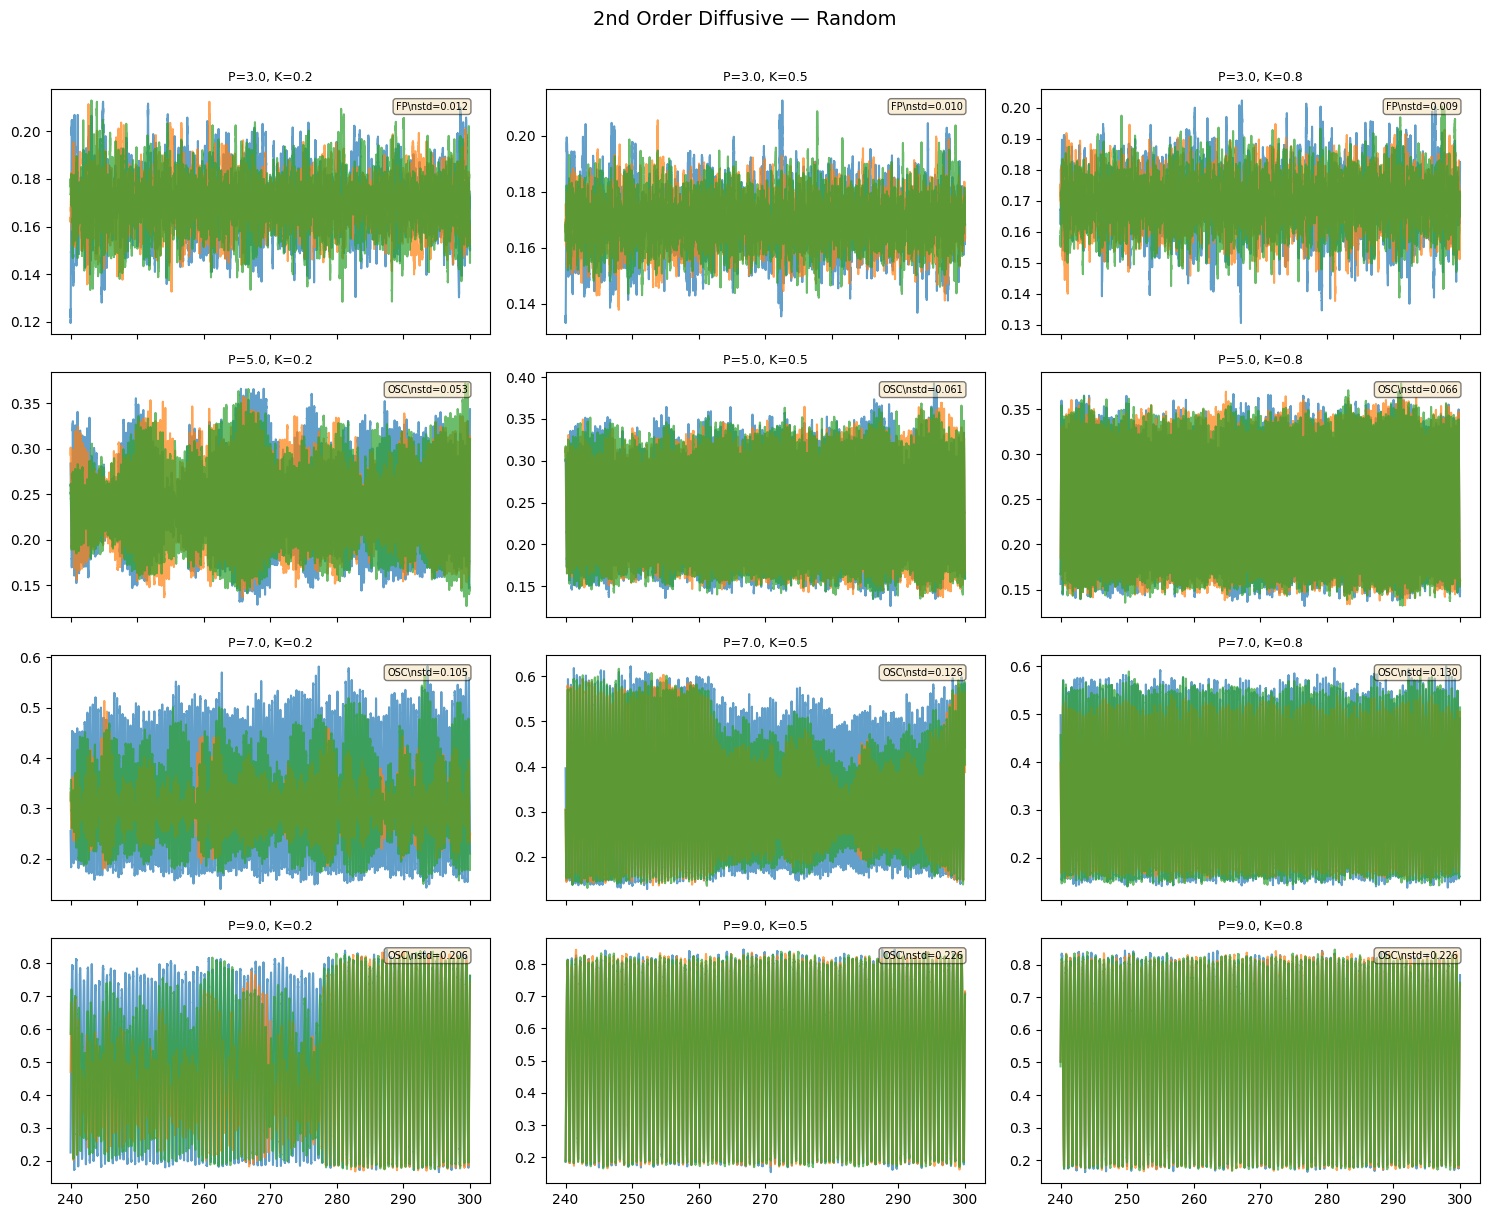

In [7]:
print('=== 2nd Order Diffusive — Random ===')
fig, axes = plt.subplots(len(P_test_values), len(K_test_values),
                         figsize=(5*len(K_test_values), 3*len(P_test_values)),
                         sharex=True)

for ip, P_val in enumerate(P_test_values):
    for ik, K_val in enumerate(K_test_values):
        P_vec = np.full(N_nodes, P_val)
        t, states = simulate_wc_additive_stochastic_10n(
            state0, P_vec, K_val, M_rand, T_test, dt, sigma_E=sigma_E)
        start = int(0.8 * len(t))
        ax = axes[ip, ik]
        for node in range(3):
            ax.plot(t[start:], states[start:, node], alpha=0.7, label=f'E{node}')
        ax.set_title(f'P={P_val}, K={K_val}', fontsize=9)
        E_last = states[start:, :N_nodes]
        amp = E_last.std(axis=0).mean()
        osc_label = 'OSC' if amp > 0.05 else 'FP'
        ax.text(0.95, 0.95, f'{osc_label}\\nstd={amp:.3f}',
                transform=ax.transAxes, fontsize=7,
                verticalalignment='top', horizontalalignment='right',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

fig.suptitle('2nd Order Diffusive — Random', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


=== 3rd Order Additive — Random ===


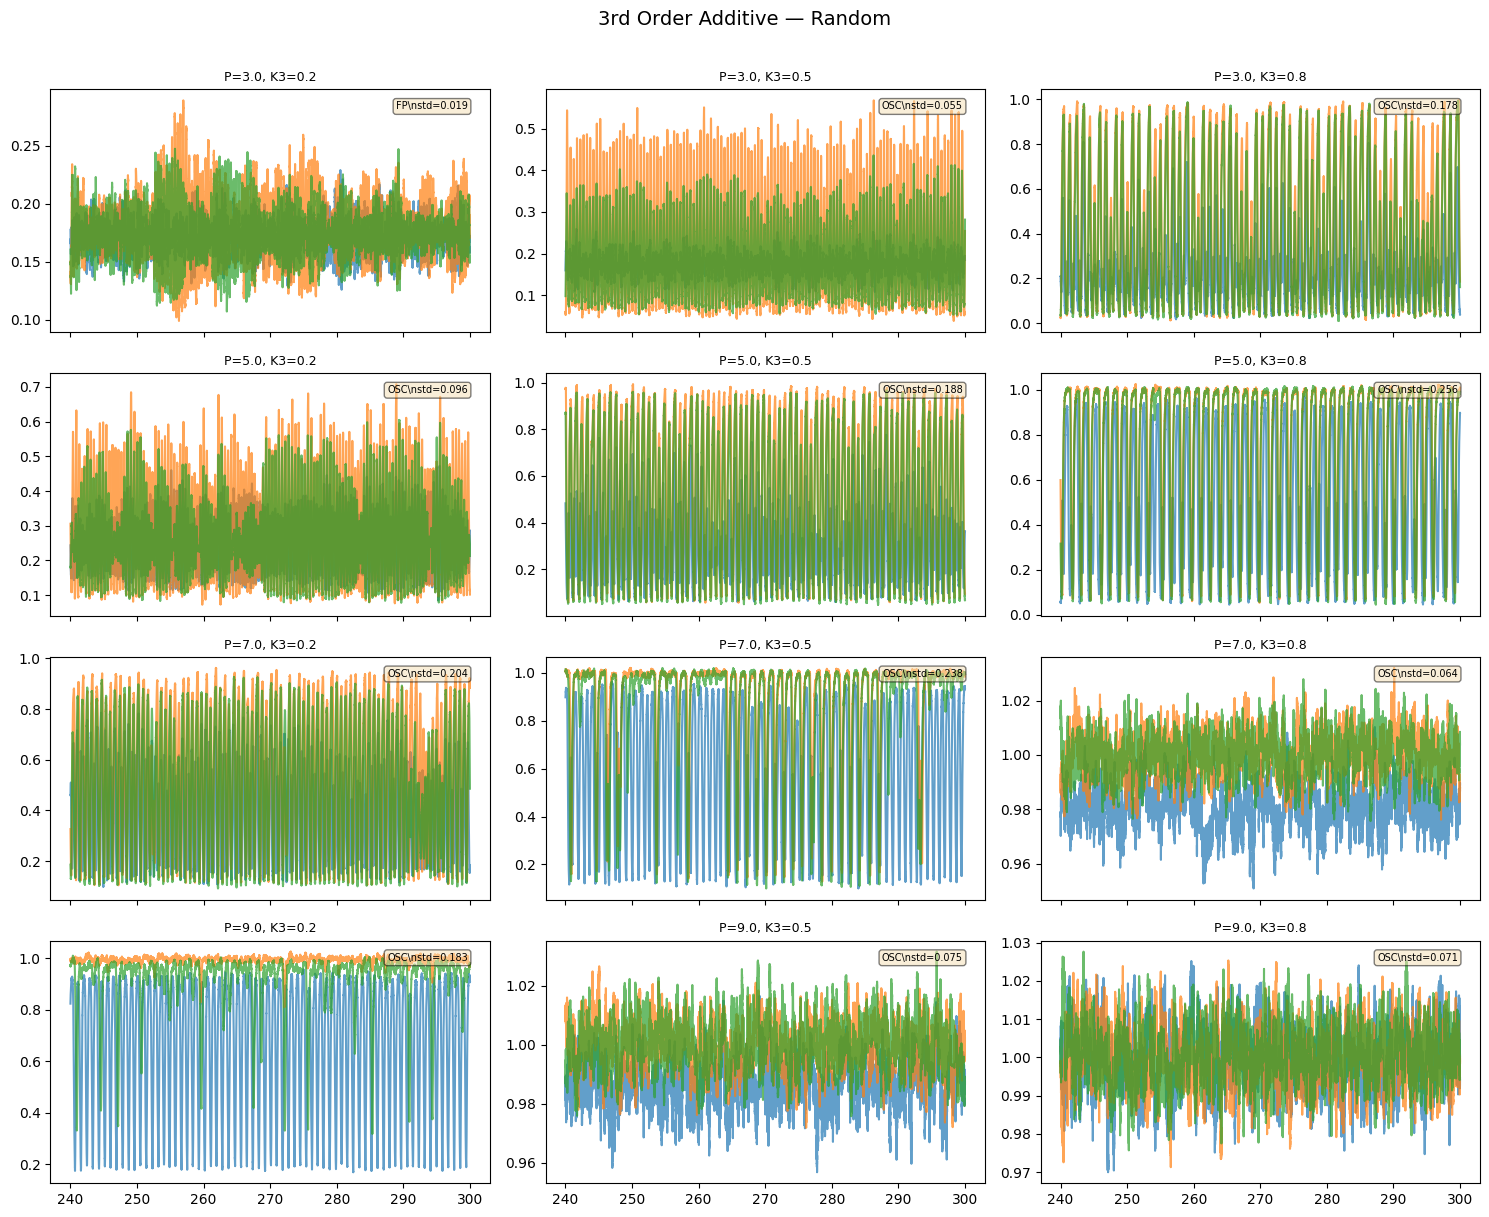

In [8]:
print('=== 3rd Order Additive — Random ===')
fig, axes = plt.subplots(len(P_test_values), len(K_test_values),
                         figsize=(5*len(K_test_values), 3*len(P_test_values)),
                         sharex=True)

for ip, P_val in enumerate(P_test_values):
    for ik, K_val in enumerate(K_test_values):
        P_vec = np.full(N_nodes, P_val)
        t, states = simulate_wc_ho_stochastic_10n(
            state0, P_vec, K_val, T_ho_rand, T_test, dt, sigma_E=sigma_E)
        start = int(0.8 * len(t))
        ax = axes[ip, ik]
        for node in range(3):
            ax.plot(t[start:], states[start:, node], alpha=0.7, label=f'E{node}')
        ax.set_title(f'P={P_val}, K3={K_val}', fontsize=9)
        E_last = states[start:, :N_nodes]
        amp = E_last.std(axis=0).mean()
        osc_label = 'OSC' if amp > 0.05 else 'FP'
        ax.text(0.95, 0.95, f'{osc_label}\\nstd={amp:.3f}',
                transform=ax.transAxes, fontsize=7,
                verticalalignment='top', horizontalalignment='right',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

fig.suptitle('3rd Order Additive — Random', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


=== 3rd Order Diffusive — Random ===


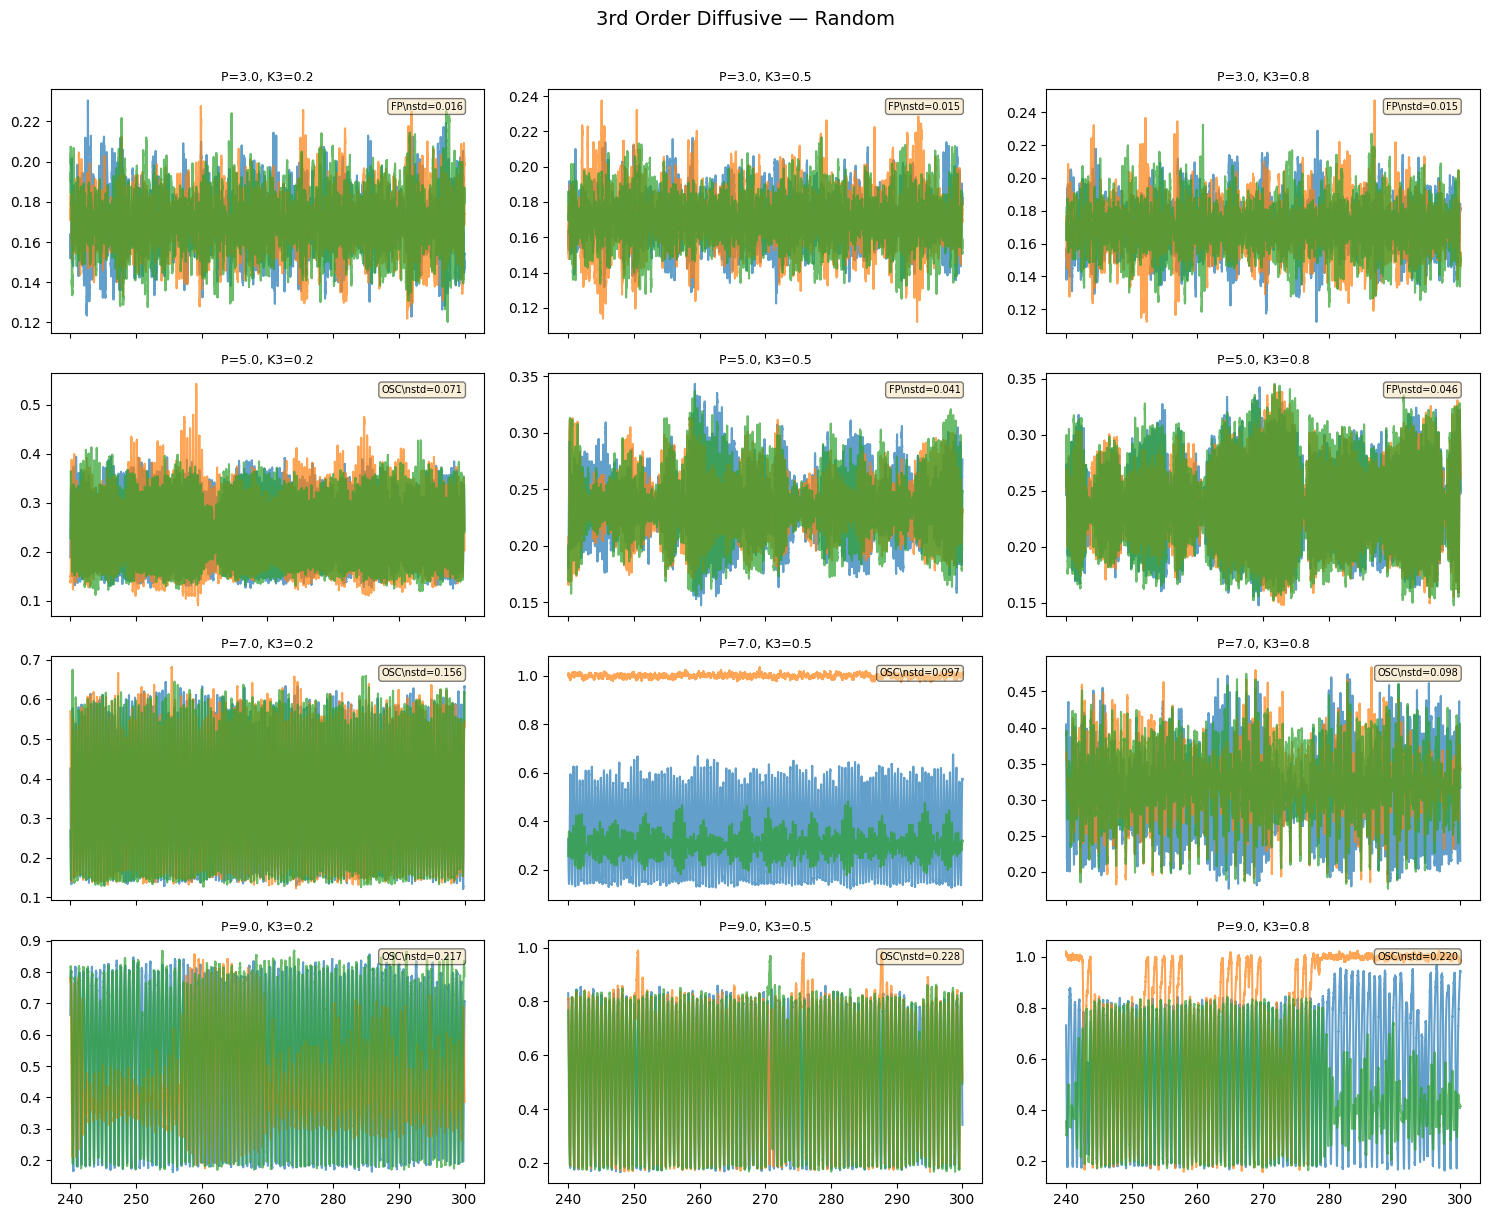

In [9]:
print('=== 3rd Order Diffusive — Random ===')
fig, axes = plt.subplots(len(P_test_values), len(K_test_values),
                         figsize=(5*len(K_test_values), 3*len(P_test_values)),
                         sharex=True)

for ip, P_val in enumerate(P_test_values):
    for ik, K_val in enumerate(K_test_values):
        P_vec = np.full(N_nodes, P_val)
        t, states = simulate_wc_ho_additive_stochastic_10n(
            state0, P_vec, K_val, T_ho_rand, T_test, dt, sigma_E=sigma_E)
        start = int(0.8 * len(t))
        ax = axes[ip, ik]
        for node in range(3):
            ax.plot(t[start:], states[start:, node], alpha=0.7, label=f'E{node}')
        ax.set_title(f'P={P_val}, K3={K_val}', fontsize=9)
        E_last = states[start:, :N_nodes]
        amp = E_last.std(axis=0).mean()
        osc_label = 'OSC' if amp > 0.05 else 'FP'
        ax.text(0.95, 0.95, f'{osc_label}\\nstd={amp:.3f}',
                transform=ax.transAxes, fontsize=7,
                verticalalignment='top', horizontalalignment='right',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

fig.suptitle('3rd Order Diffusive — Random', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


## Summary

Check the plots above:
- **OSC** = standard deviation > 0.05 (oscillatory)
- **FP** = standard deviation < 0.05 (fixed point / quiescent)

The P-K sweep in the main notebooks covers P=[0,10] and K=[0,1], so we should
see a transition somewhere in this range. If no oscillations appear, we need to
adjust the base parameters in `parameters_10nodes.py`.


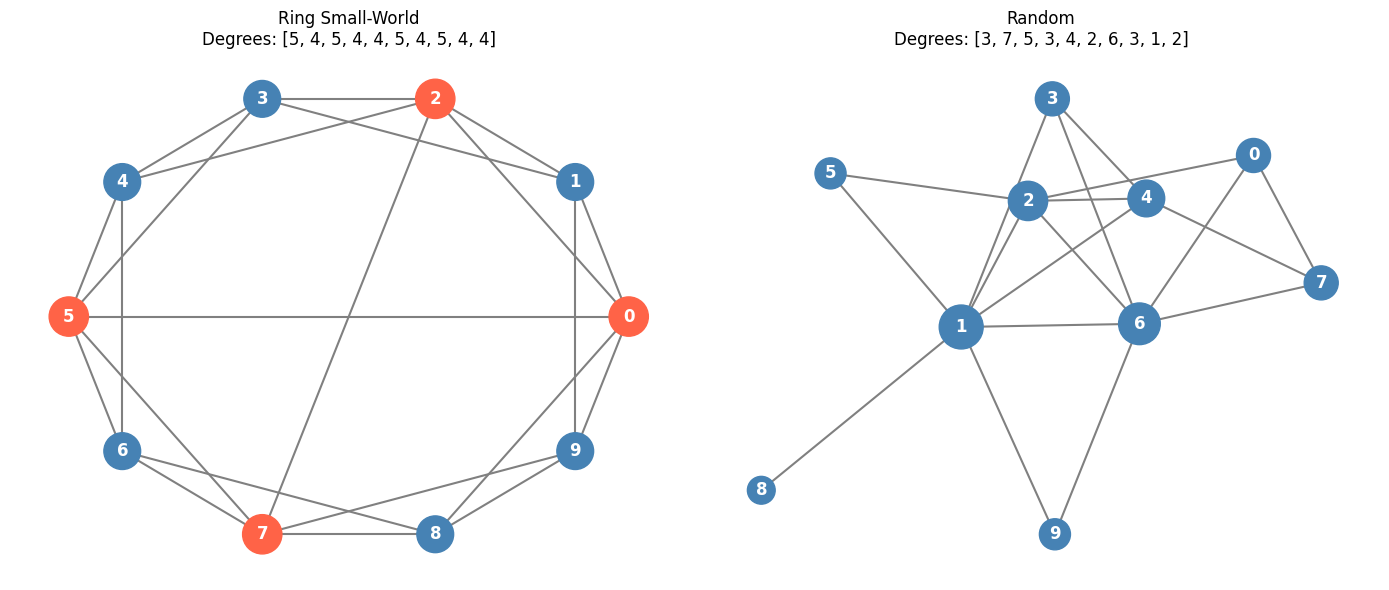

In [10]:
import networkx as nx

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Ring Small-World
G_ring = nx.from_numpy_array(M_ring)
pos_ring = nx.circular_layout(G_ring)
deg_ring = dict(G_ring.degree())
sizes_ring = [300 + 100 * deg_ring[n] for n in G_ring.nodes()]
colors_ring = ['tomato' if deg_ring[n] > 4 else 'steelblue' for n in G_ring.nodes()]
nx.draw(G_ring, pos_ring, ax=ax1, with_labels=True, node_color=colors_ring,
        node_size=sizes_ring, font_color='white', font_weight='bold',
        edge_color='gray', width=1.5)
ax1.set_title(f'Ring Small-World\nDegrees: {[deg_ring[n] for n in sorted(G_ring.nodes())]}')

# Random
G_rand = nx.from_numpy_array(M_rand)
pos_rand = nx.spring_layout(G_rand, seed=42)
deg_rand = dict(G_rand.degree())
sizes_rand = [300 + 100 * deg_rand[n] for n in G_rand.nodes()]
nx.draw(G_rand, pos_rand, ax=ax2, with_labels=True, node_color='steelblue',
        node_size=sizes_rand, font_color='white', font_weight='bold',
        edge_color='gray', width=1.5)
ax2.set_title(f'Random\nDegrees: {[deg_rand[n] for n in sorted(G_rand.nodes())]}')

plt.tight_layout()
plt.show()
